In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
project_path = Path.cwd().parent
dataset_path = project_path / "dataset"
results_path = project_path / "results"
figures_path = results_path / "figures"
models_path = results_path / "models"

figures_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

train_path = dataset_path / "train"
valid_path = dataset_path / "valid"
test_path = dataset_path / "test"

print("Project path:", project_path)
print("Dataset path:", dataset_path)
print("Train exists:", train_path.exists())
print("Valid exists:", valid_path.exists())
print("Test exists:", test_path.exists())

Project path: C:\Users\faisa\Desktop\ARTI404_Parking_Project
Dataset path: C:\Users\faisa\Desktop\ARTI404_Parking_Project\dataset
Train exists: True
Valid exists: True
Test exists: True


In [3]:
for split in ["train", "valid", "test"]:
    print("=" * 40)
    print(split.upper())
    
    for class_name in ["empty", "occupied"]:
        folder = dataset_path / split / class_name
        count = len(list(folder.glob("*.jpg")))
        print(class_name, ":", count)

TRAIN
empty : 6000
occupied : 6000
VALID
empty : 1500
occupied : 1500
TEST
empty : 1500
occupied : 1500


In [4]:
img_size = (64, 64)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    valid_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 12000 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.
Class indices: {'empty': 0, 'occupied': 1}


In [5]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
best_model_path = models_path / "best_parking_cnn_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=callbacks
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 101s 267ms/step - accuracy: 0.9215 - loss: 0.2310 - val_accuracy: 0.9707 - val_loss: 0.0860
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9616 - loss: 0.1339 - val_accuracy: 0.9857 - val_loss: 0.0563
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9644 - loss: 0.1259 - val_accuracy: 0.9743 - val_loss: 0.0723
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9668 - loss: 0.1200 - val_accuracy: 0.9780 - val_loss: 0.0672
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9714 - loss: 0.1073 - val_accuracy: 0.9733 - val_loss: 0.1241
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9707 - loss: 0.1048 - val_accuracy: 0.9940 - val_loss: 0.0307
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9724 - loss: 0.0998 - val_accuracy: 0.9910 - val_loss: 0.0566
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9726 - loss: 0.1003 

In [7]:
final_model_path = models_path / "final_parking_cnn_model.keras"
model.save(final_model_path)

print("Final model saved at:", final_model_path)
print("Best model saved at:", best_model_path)

Final model saved at: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\models\final_parking_cnn_model.keras
Best model saved at: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\models\best_parking_cnn_model.keras


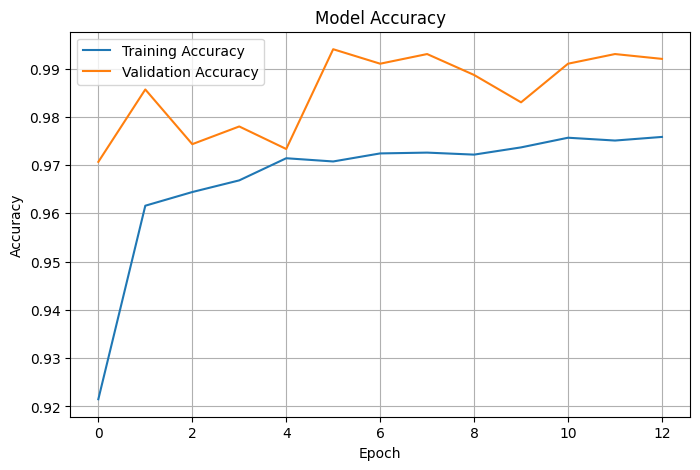

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\accuracy_curve.png


In [8]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_fig_path = figures_path / "accuracy_curve.png"
plt.savefig(accuracy_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", accuracy_fig_path)

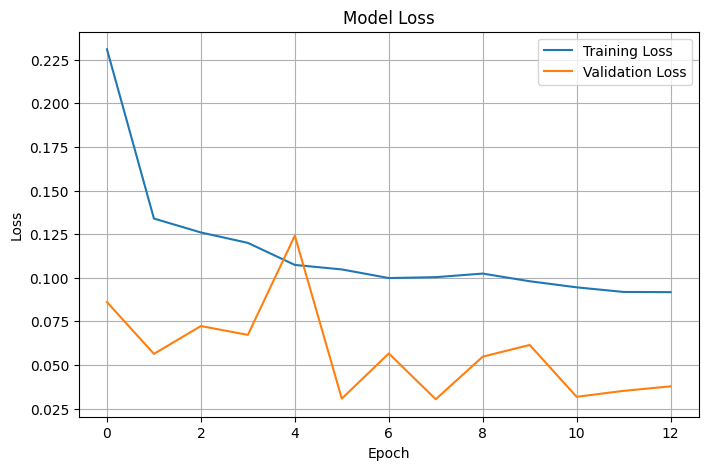

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\loss_curve.png


In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_fig_path = figures_path / "loss_curve.png"
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_fig_path)

In [10]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - accuracy: 0.9597 - loss: 0.1710
Test Loss: 0.17103753983974457
Test Accuracy: 0.9596666693687439


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Class indices: {'empty': 0, 'occupied': 1}

Classification Report:
              precision    recall  f1-score   support

       empty       1.00      0.92      0.96      1500
    occupied       0.93      1.00      0.96      1500

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



<Figure size 600x600 with 0 Axes>

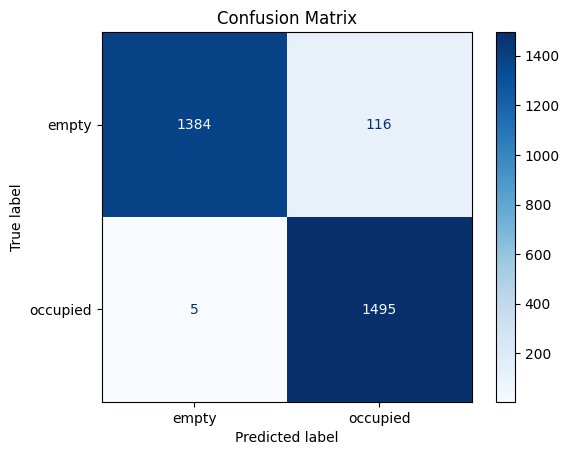

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\confusion_matrix.png


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Reset generator عشان الترتيب يكون صحيح
test_generator.reset()

# Predict probabilities
y_prob = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = (y_prob > 0.5).astype(int).ravel()

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

print("Class indices:", test_generator.class_indices)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")

confusion_fig_path = figures_path / "confusion_matrix.png"
plt.savefig(confusion_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", confusion_fig_path)

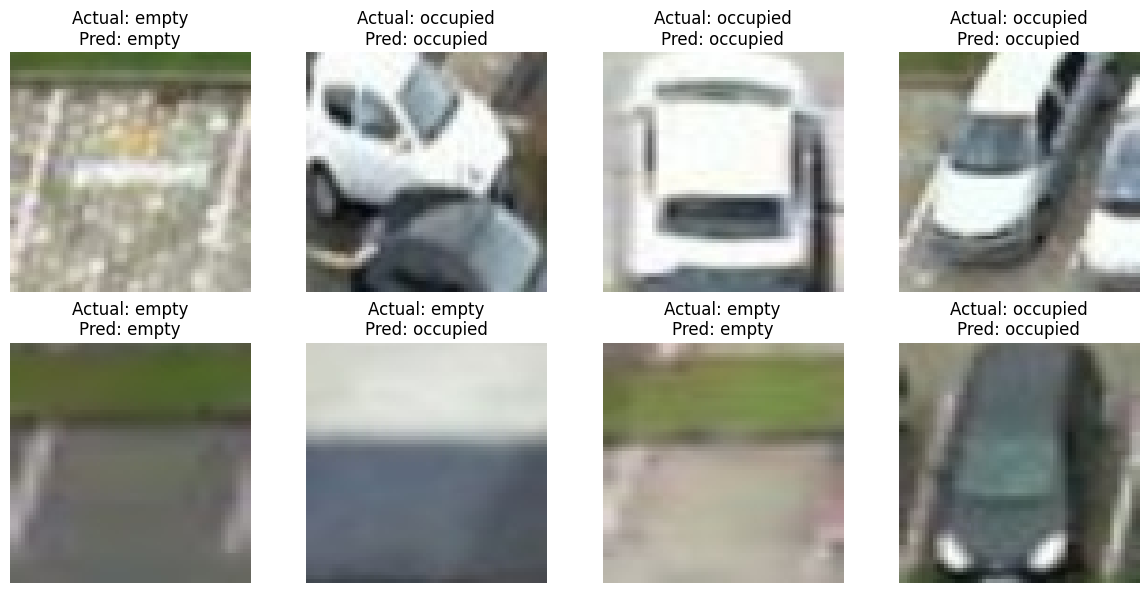

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\sample_predictions.png


In [12]:
import cv2
import random
import matplotlib.pyplot as plt
from pathlib import Path

test_empty = list((test_path / "empty").glob("*.jpg"))
test_occupied = list((test_path / "occupied").glob("*.jpg"))

sample_paths = random.sample(test_empty, 4) + random.sample(test_occupied, 4)
random.shuffle(sample_paths)

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(sample_paths):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (64, 64))
    img_normalized = img_resized / 255.0
    
    prediction = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)[0][0]
    
    predicted_label = "occupied" if prediction > 0.5 else "empty"
    actual_label = img_path.parent.name
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Actual: {actual_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()

predictions_fig_path = figures_path / "sample_predictions.png"
plt.savefig(predictions_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", predictions_fig_path)

Loaded best model: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\models\best_parking_cnn_model.keras


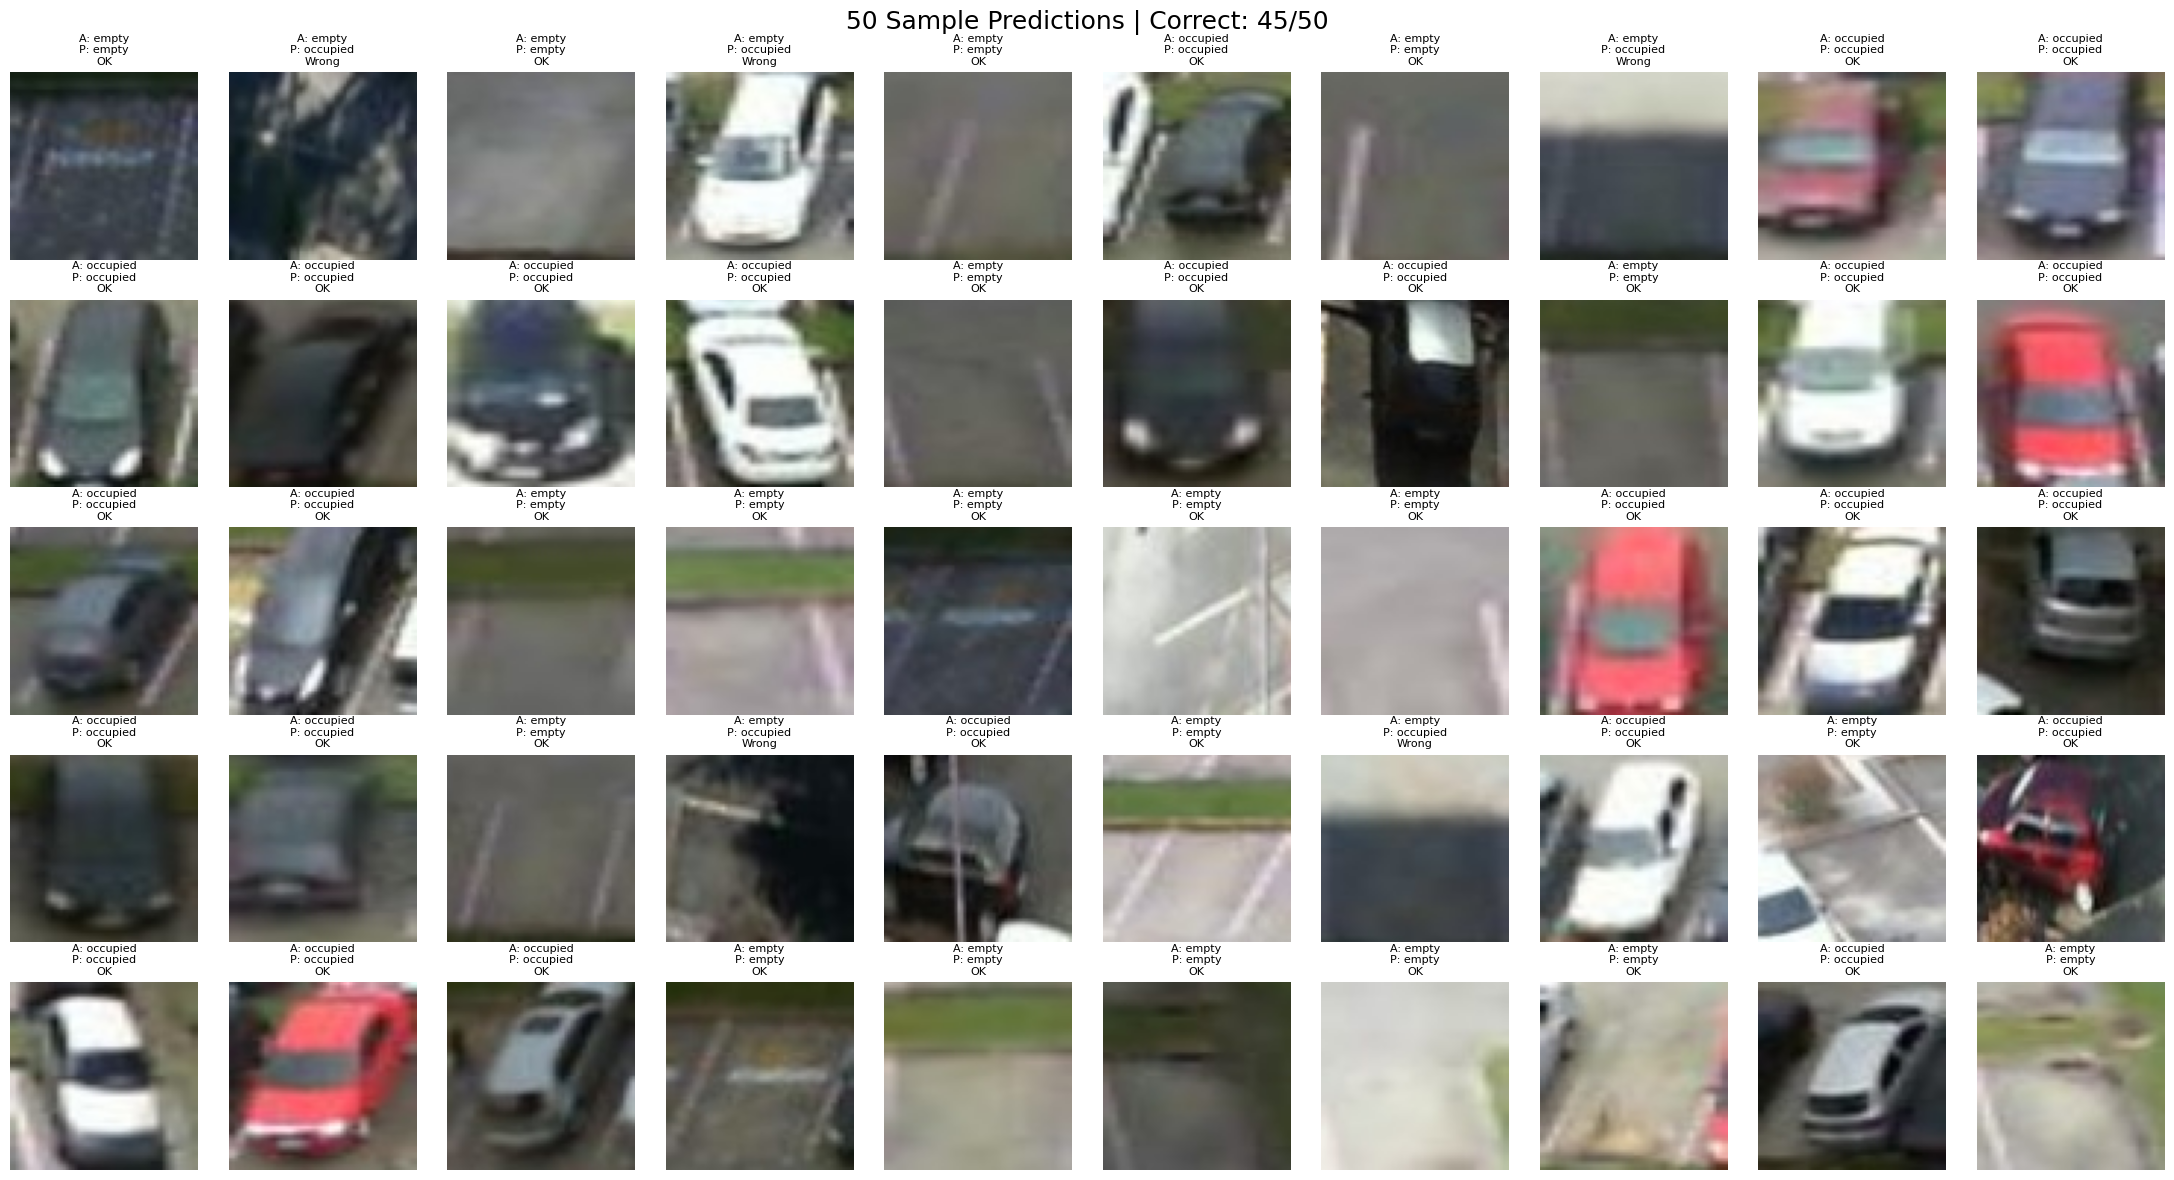

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\sample_predictions_50.png
Correct predictions: 45/50
Accuracy on these samples: 90.00%


In [2]:
import tensorflow as tf
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
project_path = Path.cwd().parent
test_path = project_path / "dataset" / "test"
figures_path = project_path / "results" / "figures"
models_path = project_path / "results" / "models"

figures_path.mkdir(parents=True, exist_ok=True)

# Load model إذا ما كان محمل
best_model_path = models_path / "best_parking_cnn_model.keras"
final_model_path = models_path / "final_parking_cnn_model.keras"

if best_model_path.exists():
    model = tf.keras.models.load_model(best_model_path)
    print("Loaded best model:", best_model_path)
else:
    model = tf.keras.models.load_model(final_model_path)
    print("Loaded final model:", final_model_path)

# Get images
test_empty = list((test_path / "empty").glob("*.jpg"))
test_occupied = list((test_path / "occupied").glob("*.jpg"))

# 25 empty + 25 occupied = 50 samples
sample_paths = random.sample(test_empty, 25) + random.sample(test_occupied, 25)
random.shuffle(sample_paths)

# Plot settings
cols = 10
rows = 5

plt.figure(figsize=(22, 12))

correct = 0

for i, img_path in enumerate(sample_paths):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    img_resized = cv2.resize(img_rgb, (64, 64))
    img_normalized = img_resized / 255.0
    
    prob = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)[0][0]
    
    predicted_label = "occupied" if prob > 0.5 else "empty"
    actual_label = img_path.parent.name
    
    if predicted_label == actual_label:
        correct += 1
        result_symbol = "OK"
    else:
        result_symbol = "Wrong"
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(
        f"A: {actual_label}\nP: {predicted_label}\n{result_symbol}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle(f"50 Sample Predictions | Correct: {correct}/50", fontsize=18)
plt.tight_layout()

save_path = figures_path / "sample_predictions_50.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)
print(f"Correct predictions: {correct}/50")
print(f"Accuracy on these samples: {(correct/50)*100:.2f}%")

In [1]:
import tensorflow as tf
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
project_path = Path.cwd().parent
test_path = project_path / "dataset" / "test"
figures_path = project_path / "results" / "figures"
models_path = project_path / "results" / "models"
results_path = project_path / "results"

figures_path.mkdir(parents=True, exist_ok=True)

# Load model
best_model_path = models_path / "best_parking_cnn_model.keras"
final_model_path = models_path / "final_parking_cnn_model.keras"

if best_model_path.exists():
    model = tf.keras.models.load_model(best_model_path)
    print("Loaded best model:", best_model_path)
else:
    model = tf.keras.models.load_model(final_model_path)
    print("Loaded final model:", final_model_path)

# Get test images
test_empty = list((test_path / "empty").glob("*.jpg"))
test_occupied = list((test_path / "occupied").glob("*.jpg"))

# 1000 empty + 1000 occupied = 2000 samples
sample_paths = random.sample(test_empty, 1000) + random.sample(test_occupied, 1000)
random.shuffle(sample_paths)

results = []
correct = 0

for img_path in sample_paths:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (64, 64))
    img_normalized = img_resized / 255.0

    prob = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)[0][0]

    predicted_label = "occupied" if prob > 0.5 else "empty"
    actual_label = img_path.parent.name

    is_correct = predicted_label == actual_label

    if is_correct:
        correct += 1

    results.append({
        "image_name": img_path.name,
        "actual": actual_label,
        "predicted": predicted_label,
        "probability_occupied": float(prob),
        "correct": is_correct
    })

accuracy_2000 = correct / len(sample_paths)

print("Total samples:", len(sample_paths))
print("Correct:", correct)
print("Wrong:", len(sample_paths) - correct)
print(f"Accuracy on 2000 samples: {accuracy_2000 * 100:.2f}%")

# Save CSV
df_results = pd.DataFrame(results)
csv_path = results_path / "predictions_2000.csv"
df_results.to_csv(csv_path, index=False)

print("CSV saved at:", csv_path)

Loaded best model: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\models\best_parking_cnn_model.keras
Total samples: 2000
Correct: 1926
Wrong: 74
Accuracy on 2000 samples: 96.30%
CSV saved at: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\predictions_2000.csv


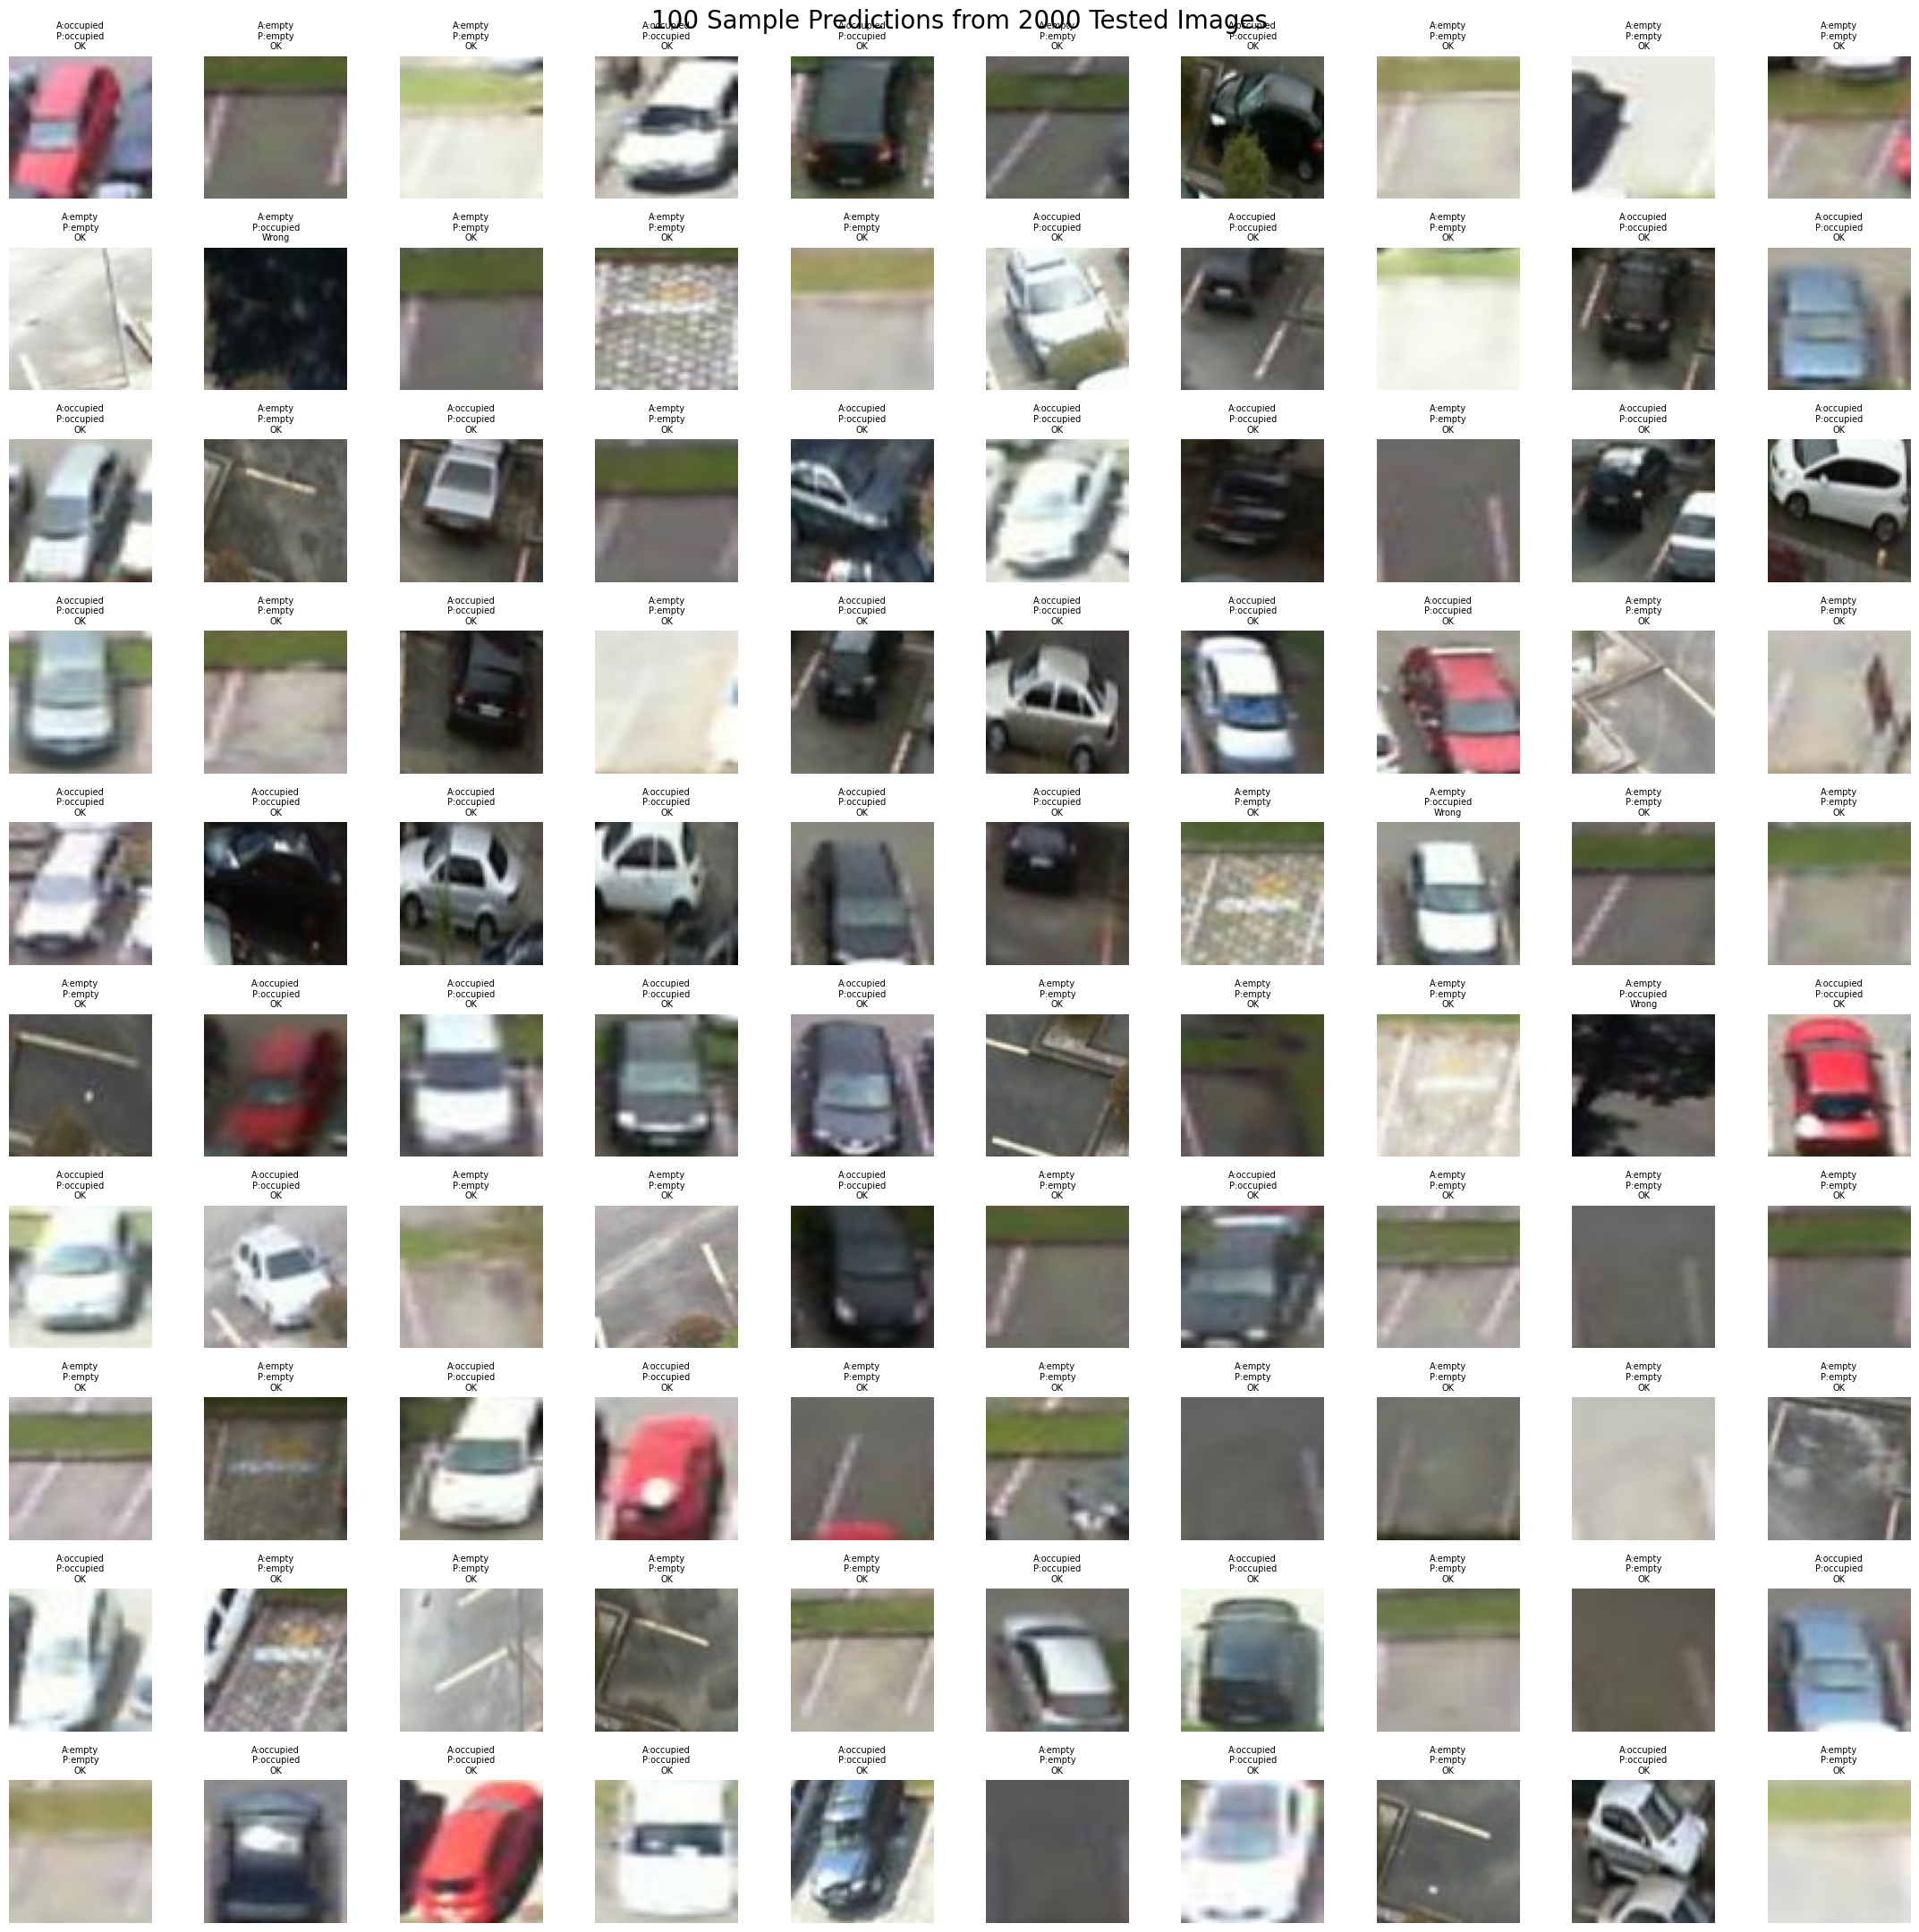

Saved: C:\Users\faisa\Desktop\ARTI404_Parking_Project\results\figures\sample_predictions_100_from_2000.png


In [2]:
# Show only first 100 samples as image grid
display_samples = sample_paths[:100]

cols = 10
rows = 10

plt.figure(figsize=(22, 22))

for i, img_path in enumerate(display_samples):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (64, 64))
    img_normalized = img_resized / 255.0

    prob = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)[0][0]

    predicted_label = "occupied" if prob > 0.5 else "empty"
    actual_label = img_path.parent.name

    result = "OK" if predicted_label == actual_label else "Wrong"

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"A:{actual_label}\nP:{predicted_label}\n{result}", fontsize=7)
    plt.axis("off")

plt.suptitle("100 Sample Predictions from 2000 Tested Images", fontsize=20)
plt.tight_layout()

save_path = figures_path / "sample_predictions_100_from_2000.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)